In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

In [34]:
def plot(time, series, x, y, name):
    if time is not None:
        plt.figure(figsize=(8, 5))
        plt.plot(time, series)
        plt.xlabel(x)
        plt.ylabel(y)
        plt.title(name)
        plt.grid(True)
        plt.show()
    else:
        plt.figure(figsize=(8, 5))
        plt.plot(series)
        plt.xlabel(x)
        plt.ylabel(y)
        plt.title(name)
        plt.grid(True)
        plt.show()

In [35]:
def to_price(sqrtPriceX96, decimals0 = 18, decimals1 = 18):
    return ((sqrtPriceX96 / (2 ** 96)) ** 2)*10**(decimals0-decimals1)

In [36]:
with open("data_from_David/wbtc_honey.json", "r") as file:
    data_wbtc = json.load(file)

display(data_wbtc)

[{'id': '0x545bea6ea7f8fd8dcc5c9a6802a8ebf3dbfc1c6e-264700',
  'liquidity': '0',
  'sqrtPriceX96': '2567285886331324574172843585078867528',
  'blockNumber': '264700',
  'feeGrowthGlobal0X128': '0',
  'feeGrowthGlobal1X128': '0',
  'feeProtocol': '229379500',
  'observationCardinality': 1,
  'observationCardinalityNext': 1,
  'observationIndex': 0,
  'price0USD': '0',
  'price1USD': '0',
  'tick': 345892,
  'timestamp': '1737882280',
  'unlocked': True,
  'token0BalanceKodiak': '0',
  'token0BalancePool': '0',
  'token1BalanceKodiak': '0',
  'token1BalancePool': '0',
  'totalSupply': '0',
  'managerToken1BalancerManager': '0',
  'managerToken0BalancerManager': '0',
  'upperTick': 887220,
  'lowerTick': -887220,
  'positionID': '0x378846d2661f4ba12a5123aa8333b1ee9ef7ae0a7b38abfcf5f9a56c96a88aaf'},
 {'id': '0x545bea6ea7f8fd8dcc5c9a6802a8ebf3dbfc1c6e-264800',
  'liquidity': '0',
  'sqrtPriceX96': '2567285886331324574172843585078867528',
  'blockNumber': '264800',
  'feeGrowthGlobal0X128': 

In [37]:
total_supply_wbtc_honey = [item['totalSupply'] for item in data_wbtc]
token1IslandBalance = [item['token1BalanceKodiak'] for item in data_wbtc]
token0IslandBalance = [item['token0BalanceKodiak'] for item in data_wbtc]
token1PoolBalance = [item['token1BalancePool'] for item in data_wbtc]
token0PoolBalance = [item['token0BalancePool'] for item in data_wbtc]
timestamp = [item['timestamp'] for item in data_wbtc]

total_supply_wbtc_honey = np.array(total_supply_wbtc_honey).astype(float)/10**18
WBTCIslandBalance = np.array(token0IslandBalance).astype(float)/10**8
HONEYIslandBalance = np.array(token1IslandBalance).astype(float)/10**18
WBTCPoolBalance = np.array(token0PoolBalance).astype(float)/10**8
HONEYPoolBalance = np.array(token1PoolBalance).astype(float)/10**18
timestamp = np.array(timestamp).astype(int)

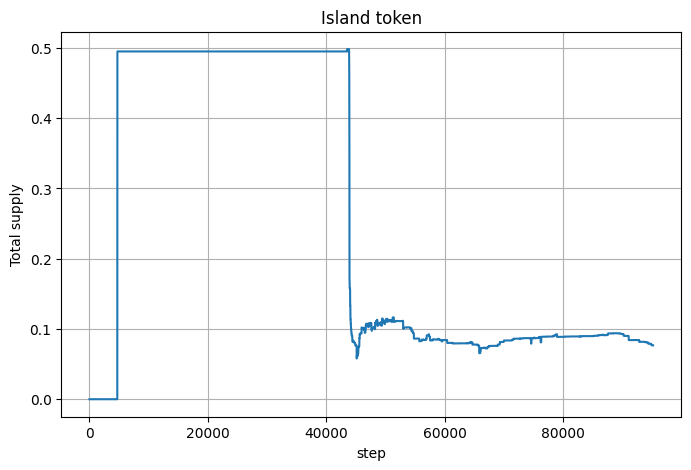

In [38]:
plot(
    None,
    total_supply_wbtc_honey,
    'step',
    'Total supply',
    'Island token'
)

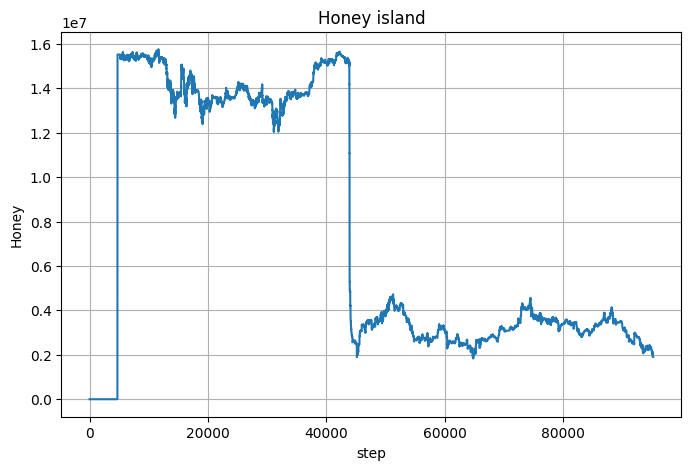

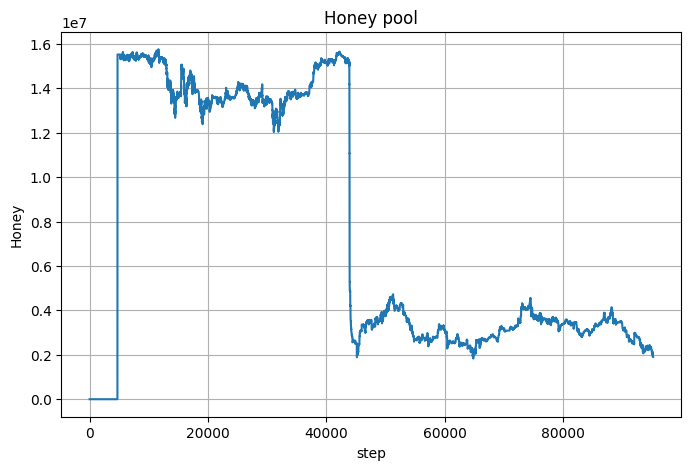

In [39]:
plot(
    None,
    HONEYIslandBalance,
    'step',
    'Honey',
    'Honey island'
)

plot(
    None,
    HONEYIslandBalance,
    'step',
    'Honey',
    'Honey pool'
)

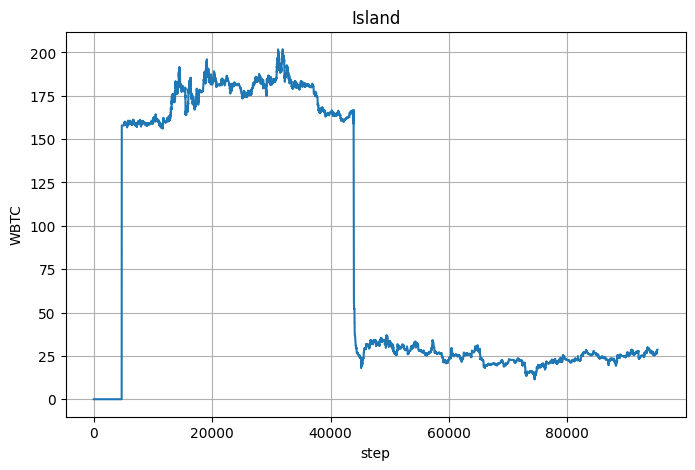

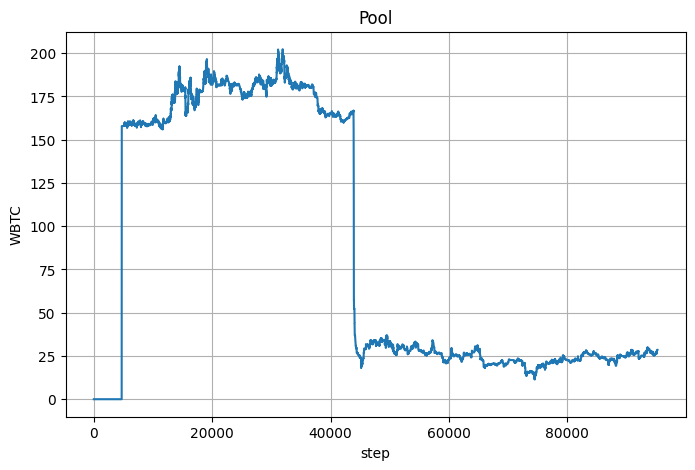

In [40]:
plot(
    None,
    WBTCIslandBalance,
    'step',
    'WBTC',
    'Island'
)

plot(
    None,
    WBTCPoolBalance,
    'step',
    'WBTC',
    'Pool'
)

In [41]:
wbtc_amounts_df = pd.DataFrame({
    'timestamp': timestamp,
    'wbtc_balance': WBTCIslandBalance,
    'honey_balance': HONEYIslandBalance,
    'island_token_balance': total_supply_wbtc_honey
})

wbtc_amounts_df.to_csv('wbtc_token_amounts_data.csv', index=False)